In [1]:
import numpy as np
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# custom 
from _config import get_prms
from _trainer import Trainer
# devisce
device = torch.device("cuda:9" if torch.cuda.is_available() else "cpu")
print(device)

seed = 1234
np.random.seed(seed)
torch.manual_seed(seed)

# problem settings : exponential, logistic, target cell-limited 
name = 'exp' # 'exp', 'log', 'virus'
meth_i = 3
dist_i = 3
methods = ['gp', 'deeponet', 'eidgm']
dist_list = ['uni', 'bi', 'tri']
dist_type = dist_list[dist_i-1] # 'uni', 'bi', 'tri'
get_plot = True

# hyperparameter settings (prms[0]:DE, prms[1]:hyperPINN, prms[2]:WGAN)
prms = get_prms(name, dist_type=dist_type) # DE / hyperPINN / WGAN settings
prms[1]['deeponet'] = (meth_i==2)
if get_plot:
    prms[2]['num_noised'] = 1000//dist_i # Insert the number of real paramaters from the each nodes with noise 
    prms[2]['num_gen_plot'] = (1000-1)*prms[2]['num_bins']
else:
    prms[2]['num_noised'] = 1000//dist_i # Insert the number of real paramaters from the each nodes with noise 
    prms[2]['num_gen_plot'] = (1000-1)*prms[2]['num_bins']
#prms[2]['num_gen_ratio'] = 1 # Insert the ratio : fake data/real data 
prms[2]['num_cut'] = 0 # Insert the number of censored time for each mode which is randomly determined via numpy seed.
#prms

cuda:9


[ total number of true data points : 4995 ]


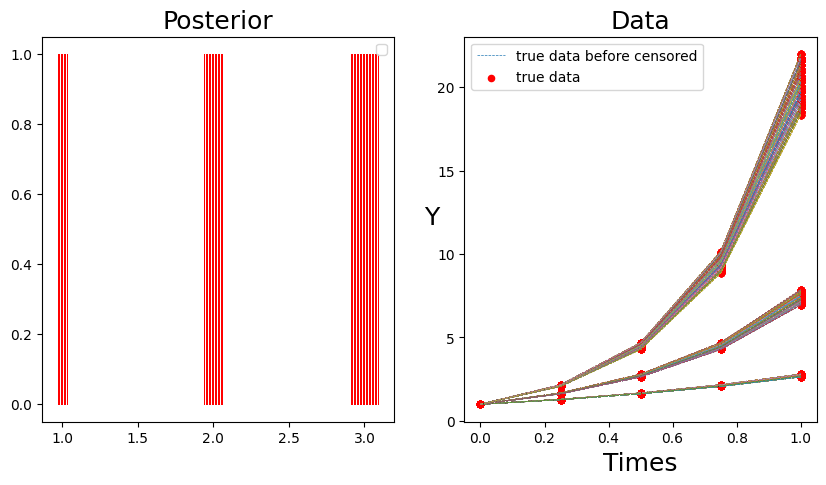

In [2]:
# get dataset : if you want real data 
real_data = None # None, 'Abeta40', 'Abeta42'
trainer = Trainer(name, prms, device=device)
modes_noisy, X_data, X_data_onehot = trainer.get_data_gan(real_data=real_data)

> model output : gp / deeponet / hyperpinn 

WD:  0.031651149503819524


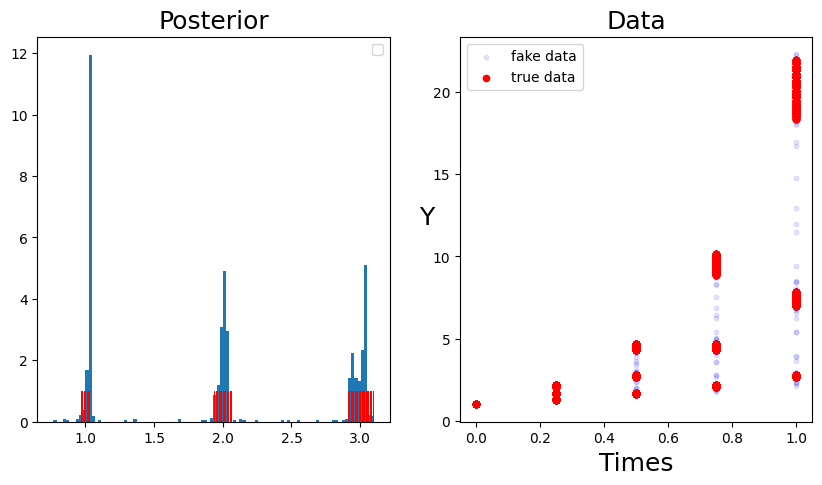

999 1000


In [3]:
if meth_i in [2,3]:
    # prepare models
    # load pre-trained hyperPINNs
    trainer.load_pinn()

    # load WGANs
    load_params = True # if you want to train WGAN from the begining, then this should be False.
    trainer.load_gan(load_params=load_params)

    # show WGAN result
    gens = trainer.plot_results_gan(modes_noisy, X_data, plot_traj=False, return_gen=True, get_scores=True)

    print(len(modes_noisy), len(gens))
else:
    # GET GP save files
    gens = torch.load('./save/GP/gp_'+trainer.name+str(trainer.num_modes)+'.pth')
    print(len(modes_noisy), len(gens), trainer.WD(gens, modes_noisy))

> plot

In [4]:
trues = pd.DataFrame(np.concatenate([modes_noisy.numpy(), np.reshape(np.array([['true']*len(modes_noisy)]),(-1,1))],-1), columns=trainer.param_names+[' ']).astype({key:float for key in trainer.param_names})
fakes = pd.DataFrame(np.concatenate([gens.numpy(), np.reshape(np.array([['estimated']*len(gens)]),(-1,1))],-1), columns=trainer.param_names+[' ']).astype({key:float for key in trainer.param_names})
df = pd.concat([fakes, trues])

cc = ['magenta','blue','green']
tc = cc[dist_i-1]
sns.set(font_scale=3)
sns.set_style("ticks", {'axes.grid' : False})

c_mod = tc
num_bins = trainer.num_bins
tmin, tmax = trainer.tmin, trainer.tmax
x_bins = trainer.t_numpy
t = np.linspace(tmin,tmax,num_bins)
t_torch = torch.linspace(tmin,tmax,num_bins)
y_values = []
for mod in modes_noisy:
    y_values.append(trainer.solution(torch.cat([t_torch.view(-1,1), mod.view(-1,trainer.num_p).repeat(num_bins,1)], -1)))
    
if dist_i==1:
    fs = 32
    xlb1=False
    ylb1=False
if dist_i==2:
    fs = 32
    xlb1=False
    ylb1=True
if dist_i==3:
    fs = 35
    xlb1=True
    ylb1=False
bw = 0.1

In [5]:
if meth_i == 1:
    # true data plot 
    fig, axs = plt.subplots(1, 1, figsize=(5+1*int(ylb1)+0.3*int(xlb1), 5+0.9*int(xlb1)), dpi=300)
    #fig, axs = plt.figure(figsize=(6, 4.5), dpi=300)
    # Solve and plot trajectories
    # plot traj
    k = 0
    for yval in y_values:
        cp2 = axs.scatter(t_torch, yval[:,k], color=tc, s=40, alpha=1)

    # Plot formatting
    axs.set_xlim([-0.05, 1.05])
    axs.set_ylim([0, 25])
    axs.set_yticks([1, 12, 24])
    axs.set_xticks([0, 0.5, 1])
    #axs.set_yscale('log')
    if xlb1:
        axs.set_xlabel('Time', fontsize=fs)  # Larger font size for formal papers
    else:
        axs.set_xlabel('', fontsize=fs)  # Larger font size for formal papers
        axs.set_xticklabels([])
    if ylb1:
        axs.set_ylabel('Population', fontsize=fs)  # Larger font size for formal papers
    else:
        axs.set_ylabel('', fontsize=fs)  # Larger font size for formal papers
        axs.set_yticklabels([])
    axs.tick_params(axis='both', which='major', labelsize=fs)
    for axis in ['bottom','left']:
        axs.spines[axis].set_linewidth(4)
    for axis in ['top','right']:
        axs.spines[axis].set_linewidth(0)
    axs.xaxis.set_tick_params(width=3)
    axs.yaxis.set_tick_params(width=3)
    #plt.title('Observation', fontsize=16, fontweight='bold')  # Title for the plot
    # Use a tight layout to ensure everything fits without overlap
    plt.tight_layout()
    # Save the figure with high resolution for better clarity in the paper
    plt.savefig('./eps/exp'+str(dist_i)+'_traj.eps', format='eps', dpi=300)
    # Show the plot
    plt.show()

In [6]:
fs = 27
if dist_i == 1:
    xlb1 = False
    bw = 1.5
if dist_i == 2:
    xlb1 = True
    bw = 0.2
if dist_i == 3:
    xlb1 = False
    bw = 0.2

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


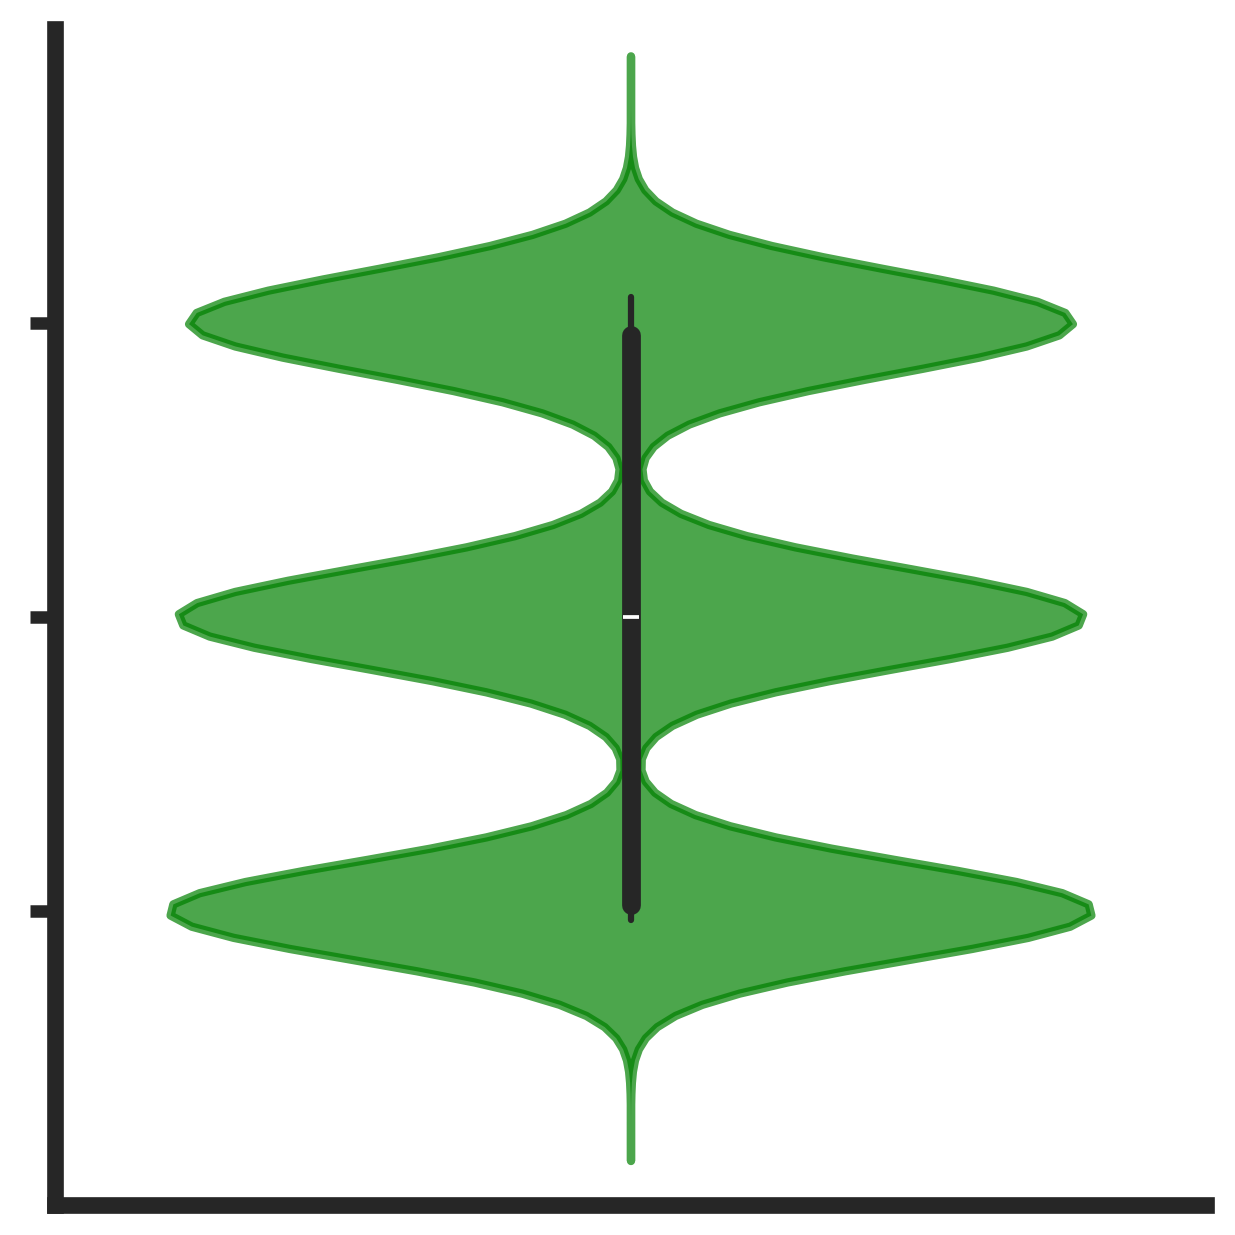

In [7]:
plt.figure(figsize=(5+1*int(ylb1),5), dpi=300)
if dist_i == 1:
    g = sns.violinplot(df.loc[df[' '] == 'true', 'r'], cut=5, palette=[c_mod], bw=5, scale="count", linewidth=1)
else:
    g = sns.violinplot(df.loc[df[' '] == 'true', 'r'], color=tc, bw_method=bw, density_norm='width', cut=5, linewidth=1)
for axis in ['bottom','left']:
    g.spines[axis].set_linewidth(4)
for axis in ['top','right']:
    g.spines[axis].set_linewidth(0)
if ylb1:
    g.set(xlabel='', ylabel='r', yticks=[1,2,3], ylim=[0,4], xticks=[])
else:
    g.set(xlabel='', ylabel='',yticks=[1,2,3], ylim=[0,4], yticklabels=[], xticks=[])
violins = [c for i, c in enumerate(g.collections) if i%2 == 0]  
[v.set_edgecolor(tc) for v in violins]
[v.set_linewidth(2)  for v in violins]
[v.set_facecolor(tc) for v in violins] 
[v.set_alpha(0.7) for v in violins] 
g.yaxis.set_tick_params(width=3)
plt.tight_layout()
plt.savefig('./eps/'+trainer.filename+'_true.eps', format='eps', dpi=300)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


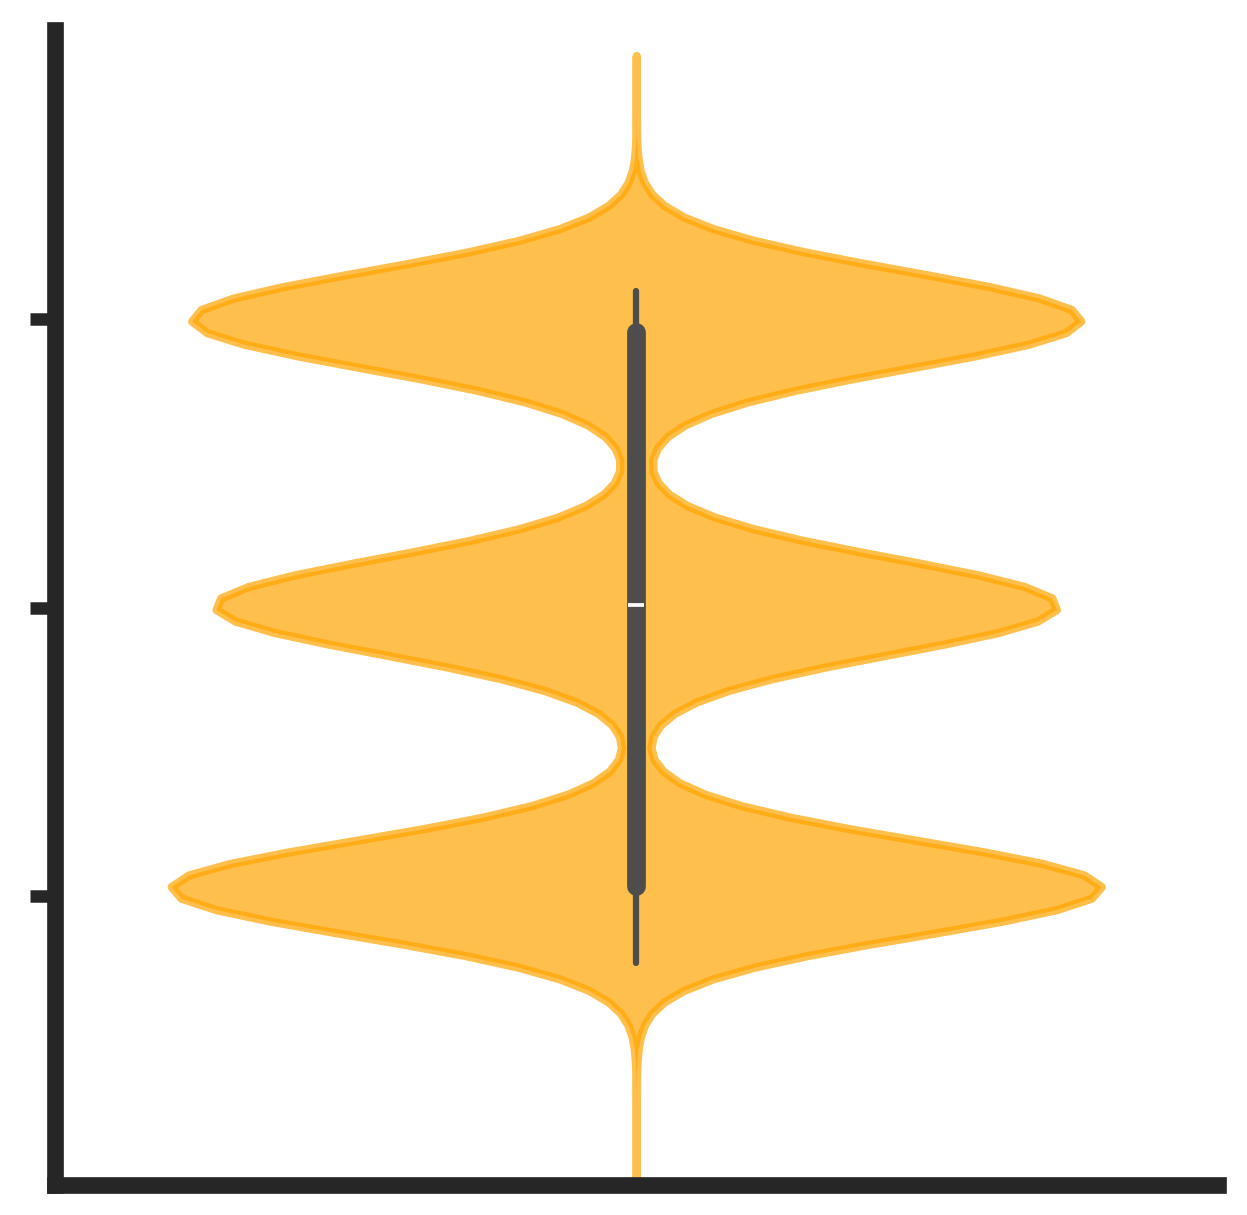

In [8]:
xlb1 = False
plt.figure(figsize=(5,5), dpi=300)
if dist_i == 1:
    g = sns.violinplot(df.loc[df[' '] == 'estimated', 'r'], color='red', cut=5, bw=5, scale="count", linewidth=1)
else:
    g = sns.violinplot(df.loc[df[' '] == 'estimated', 'r'], color='red', linewidth=1, bw_method=0.2, density_norm='width', cut=5)
for axis in ['bottom','left']:
    g.spines[axis].set_linewidth(4)
for axis in ['top','right']:
    g.spines[axis].set_linewidth(0)
if xlb1:
    g.set(xlabel='', ylabel='r', yticks=[1,2,3], ylim=[0,4], xticks=[])
else:
    g.set(xlabel='', ylabel='',yticks=[1,2,3], ylim=[0,4], yticklabels=[], xticks=[])
violins = [c for i, c in enumerate(g.collections) if i%2 == 0]  
[v.set_edgecolor("orange") for v in violins]
[v.set_linewidth(2)  for v in violins]
[v.set_facecolor("orange") for v in violins] 
[v.set_alpha(0.7) for v in violins] 
g.yaxis.set_tick_params(width=3)
plt.savefig('./eps/exp'+str(dist_i)+'_'+methods[meth_i-1]+'_fake.eps', format='eps', dpi=300)
plt.show()